# TritonBench-T: a Didactic Walkthrough of PyTorch → Triton Translation

**Can an LLM rewrite a PyTorch operator as a fused Triton kernel?**

This notebook is a hands-on tour of the *translation* track of
[TritonBench](https://github.com/thunlp/TritonBench). We will send three
PyTorch operators to a real LLM, ask it to translate them to Triton, and run
the answers through the benchmark's runtime metrics on a single Colab GPU.

## Learning objectives

1. Describe how TritonBench-T differs from TritonBench-G: the input is
   *source code*, not a natural-language spec, and there is no CodeBLEU.
2. Recognize three canonical translation patterns: pointwise, pointwise with
   a configuration branch, and reduction.
3. Reproduce the three runtime metrics (call@1, exe@1, speedup) on a live
   LLM response.
4. Explain why a Triton translation can pass call@1 yet still fail exe@1, and
   construct such a case deliberately.

## Runtime requirements

GPU Colab runtime (*Runtime → Change runtime type → GPU*, T4 is fine) **and**
an API key for [**NVIDIA's model API**](https://build.nvidia.com) (free tier
works). The notebook has a hand-written fallback for every step, so it still
runs end-to-end without an API key — you just won't see real LLM variability.

Estimated runtime: 5–10 minutes on T4.

---

*Based on the paper* TRITONBENCH: Benchmarking Large Language Model
Capabilities for Generating Triton Operators *(arXiv:2502.14752) and the
reference code at https://github.com/thunlp/TritonBench.*


In [7]:
pip install -q -U google-genai


## 1. Why translation is interesting

Most real GPU optimization work is not "write a Triton kernel from scratch"
— it is "I have this PyTorch operator and I need it ten times faster."
That reframes the problem in two ways that matter:

- The **input** is already unambiguous: a working PyTorch function with a
  known numerical behavior. The LLM does not have to invent semantics.
- The **target** is open-ended: *any* Triton implementation that produces the
  same outputs and runs faster is acceptable. There is no single "right
  answer" to match against.

That second point is why TritonBench-T drops CodeBLEU. Text similarity to a
specific reference is actively misleading when the reference itself is
underdetermined — a fused Triton kernel usually looks nothing like the
PyTorch source it replaces.


## 2. The three runtime metrics

| Metric | What it asks | How it is computed |
|---|---|---|
| **call@1** | Does the generated code import and run at all? | Concatenate predicted code with the benchmark test, run as a subprocess, check return code. |
| **exe@1** | Does it produce numerically correct output? | Run reference PyTorch and predicted Triton on identical inputs, compare the `test_results` dicts with `torch.allclose`. |
| **speedup** | Is it actually faster than PyTorch? | For kernels that pass exe@1, time both with `torch.cuda.Event`; report the ratio. |

Each metric is a tighter sieve than the last. A kernel that passes all three
is a kernel worth keeping.


## 3. Environment setup


In [8]:
import subprocess, sys, os

# GPU check
try:
    out = subprocess.check_output(["nvidia-smi",
                                   "--query-gpu=name,memory.total,driver_version",
                                   "--format=csv,noheader"]).decode().strip()
    print("GPU detected:", out)
except Exception:
    print("No GPU found — switch the Colab runtime to GPU (Runtime → Change runtime type → GPU).")
    raise SystemExit(1)

import torch, triton
print("torch  :", torch.__version__)
print("triton :", triton.__version__)
assert torch.cuda.is_available()


GPU detected: Tesla T4, 15360 MiB, 580.82.07
torch  : 2.10.0+cu128
triton : 3.6.0


### Configure your NVIDIA API access

NVIDIA exposes its hosted models via an **OpenAI-compatible** endpoint at
`https://integrate.api.nvidia.com/v1`, so the standard `openai` SDK works —
we just point it at a different `base_url`. Free-tier keys are available at
<https://build.nvidia.com>.

#### Step 1 — Store the API key as a Colab Secret

This keeps your key out of the notebook file (so you can share the notebook
without leaking credentials). In Colab:

1. Click the **🔑 key icon** on the left sidebar ("Secrets").
2. Click **+ Add new secret**.
3. Name it exactly `NVIDIA_API_KEY`.
4. Paste your NVIDIA key (it starts with `nvapi-…`) into the *Value* field.
5. Toggle **Notebook access** on for this notebook.

If the secret is unavailable (e.g., you are not on Colab) the cell below
falls back to a silent `getpass` prompt; if that is also blank, the notebook
uses its hand-written Triton translations.

#### Step 2 — Install the `openai` SDK

The OpenAI SDK is what we use to talk to NVIDIA's endpoint. One short
install:


In [9]:
import subprocess, sys

def _pip(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import openai
except ImportError:
    _pip("openai"); import openai
print("openai SDK:", openai.__version__)


openai SDK: 2.32.0


#### Step 3 — Configure the client

You rarely need to change these defaults. The only thing you might tweak is
`NVIDIA_MODEL` if you want to try a different model from the NVIDIA catalog
(e.g., `meta/llama-3.1-70b-instruct`, `nvidia/llama-3.1-nemotron-70b-instruct`,
`qwen/qwen2.5-coder-32b-instruct`). Browse all hosted models at
<https://build.nvidia.com/explore/discover>.


In [10]:
from google import genai
import os # Added import os

# The client gets the API key from the environment variable `GEMINI_API_KEY`.
gemini_api_key = os.getenv("GEMINI_API_KEY")
if gemini_api_key:
    client = genai.Client(api_key=gemini_api_key)

    response = client.models.generate_content(
        model="gemini-3-flash-preview", contents="Explain how AI works in a few words"
    )
    print(response.text)
else:
    print("GEMINI_API_KEY environment variable not set. Please set it to use the Genai client.")


GEMINI_API_KEY environment variable not set. Please set it to use the Genai client.


In [11]:
# ---- NVIDIA endpoint configuration -----------------------------------------
NVIDIA_BASE_URL = "https://integrate.api.nvidia.com/v1"
NVIDIA_MODEL    = "mistralai/devstral-2-123b-instruct-2512"
# ----------------------------------------------------------------------------

# Try Colab Secrets first, then getpass, then "no key -> use fallbacks".
API_KEY = ""
try:
    from google.colab import userdata   # type: ignore
    try:
        API_KEY = (userdata.get("NVIDIA_API_KEY") or "").strip()
        if API_KEY:
            print("Loaded NVIDIA_API_KEY from Colab Secrets.")
    except Exception as e:
        # SecretNotFoundError or NotebookAccessError
        print(f"Colab secret not accessible ({type(e).__name__}). Falling back to getpass.")
except ImportError:
    pass

if not API_KEY:
    from getpass import getpass
    API_KEY = getpass("NVIDIA API key (blank = fallback): ").strip()

USE_LLM = bool(API_KEY)
print(f"USE_LLM = {USE_LLM}   (model = {NVIDIA_MODEL})")

from openai import OpenAI
nvidia_client = OpenAI(base_url=NVIDIA_BASE_URL, api_key=API_KEY) if USE_LLM else None


Loaded NVIDIA_API_KEY from Colab Secrets.
USE_LLM = True   (model = mistralai/devstral-2-123b-instruct-2512)


### A thin `call_llm` wrapper

Streams a chat-completions request to the NVIDIA endpoint. Streaming serves
two purposes here: (a) students can optionally see tokens arrive live (set
`stream_print=True`), and (b) it matches the official NVIDIA snippet. We
still accumulate the full text before returning, so the rest of the pipeline
can work with a single string.

Defaults mirror NVIDIA's suggested generation parameters:
`temperature=0.15`, `top_p=0.95`, `max_tokens=8192`, `seed=42`.


In [12]:
def call_llm(prompt: str,
             max_tokens: int = 8192,
             temperature: float = 0.15,
             top_p: float = 0.95,
             seed: int = 42,
             stream_print: bool = False):
    '''Call the configured NVIDIA model. Returns str, or None on failure.'''
    if not USE_LLM:
        return None
    try:
        stream = nvidia_client.chat.completions.create(
            model=NVIDIA_MODEL,
            messages=[
                {"role": "system",
                 "content": "You are an expert in writing Triton GPU kernels."},
                {"role": "user", "content": prompt},
            ],
            temperature=temperature,
            top_p=top_p,
            max_tokens=max_tokens,
            seed=seed,
            stream=True,
        )
        parts = []
        for chunk in stream:
            if chunk.choices and chunk.choices[0].delta.content is not None:
                piece = chunk.choices[0].delta.content
                if stream_print:
                    print(piece, end="", flush=True)
                parts.append(piece)
        if stream_print:
            print()
        return "".join(parts)
    except Exception as e:
        print(f"[call_llm] {type(e).__name__}: {str(e)[:200]} — falling back.")
        return None


### Fetch the TritonBench-T data


In [13]:
import os, urllib.request

REPO_URL = "https://github.com/thunlp/TritonBench.git"
ROOT = "/content/TritonBench" if os.path.isdir("/content") else "/tmp/TritonBench"

if not os.path.isdir(ROOT):
    rc = os.system(f"git clone --depth 1 {REPO_URL} {ROOT} 2>&1 | tail -3")

BASE = "https://raw.githubusercontent.com/thunlp/TritonBench/main"
NEEDED = [
    "data/TritonBench_T_simp_alpac_v1.json",
    "data/TritonBench_T_v1/add.py",
    "data/TritonBench_T_v1/gelu.py",
    "data/TritonBench_T_v1/mean.py",
]
for rel in NEEDED:
    dst = os.path.join(ROOT, rel)
    if not os.path.isfile(dst):
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        urllib.request.urlretrieve(f"{BASE}/{rel}", dst)
    print("OK", dst)


OK /content/TritonBench/data/TritonBench_T_simp_alpac_v1.json
OK /content/TritonBench/data/TritonBench_T_v1/add.py
OK /content/TritonBench/data/TritonBench_T_v1/gelu.py
OK /content/TritonBench/data/TritonBench_T_v1/mean.py


## 4. What does the LLM actually see?

Open the Alpaca JSON for the *simple* instruction set. Each entry has the
PyTorch function description, signature, and math embedded in the
`instruction` field; the `input` and `output` fields are empty (the LLM
should fill in `output` with a Triton translation).


In [14]:
import json
with open(f"{ROOT}/data/TritonBench_T_simp_alpac_v1.json") as f:
    T_simp = json.load(f)

# Find the three kernels we care about
CHOSEN = ["add.py", "gelu.py", "mean.py"]

def find_entry(name):
    for e in T_simp:
        if name in e["instruction"]:
            return e
    raise KeyError(name)

print(f"Total T-simple prompts: {len(T_simp)}\n")
print("=" * 80)
print("EXAMPLE: instruction for add.py  (first 900 chars)")
print("=" * 80)
print(find_entry("add")["instruction"][:900], "...")


Total T-simple prompts: 166

EXAMPLE: instruction for add.py  (first 900 chars)
You are an expert in Trion programming, capable of writing corresponding Triton kernels and wrapper functions based on functional descriptions and function parameters. Ensure that the wrapper function fully corresponds to the provided function information.
Functional Description: Performs a fused operation combining batch matrix multiplication, RMS normalization, GELU activation, dropout, and subtraction. The function takes three input tensors, performs batch matrix multiplication on the first two, applies RMS normalization, GELU activation, and dropout, and finally subtracts the third tensor from the result.
Wrapper Entry Information: fused_bmm_rmsnorm_gelu_dropout_sub(input1, input2, other, normalized_shape, dropout_p=0.5, training=True, approximate='none', eps=1e-5, *, out=None) -> Tensor. Args: input1 (Tensor): First input tensor for batch matrix multiplication, of shape (B, N, M), w ...


## 5. The reference PyTorch file

Each kernel's reference lives at `data/TritonBench_T_v1/<name>.py`. The file
is split by the usual `#`×146 divider into two halves:

- **Top half** — the PyTorch implementation. *This is what the LLM must
  replace with Triton.*
- **Bottom half** — a `def test_<name>()` harness that stores outputs in a
  `test_results` dict.

Unlike TritonBench-G, the top half is pure PyTorch, so running the reference
file gives us the **ground-truth outputs** for exe@1 for free.


In [15]:
DIVIDER = "#" * 146

def load_ref(name):
    with open(f"{ROOT}/data/TritonBench_T_v1/{name}") as f:
        return f.read()

def split_ref(name):
    src = load_ref(name)
    if DIVIDER in src:
        top, bot = src.split(DIVIDER, 1)
    else:
        parts = src.split("#" * 50, 1)
        top, bot = parts[0], parts[1] if len(parts) > 1 else ""
    return top.strip(), bot.strip()

top, bot = split_ref("gelu.py")
print("--- PYTORCH SOURCE (top half) ---")
print(top)
print("\n--- TEST HARNESS (bottom half) ---")
print(bot)


--- PYTORCH SOURCE (top half) ---
import torch
import torch.nn.functional as F

def gelu(input: torch.Tensor, approximate: str='none') -> torch.Tensor:
    return F.gelu(input, approximate=approximate)

--- TEST HARNESS (bottom half) ---
import torch
import torch.nn.functional as F

# def gelu(input: torch.Tensor, approximate: str='none') -> torch.Tensor:
#     return F.gelu(input, approximate=approximate)

def test_gelu():
    results = {}
    
    # Test case 1: Default approximate='none'
    input_tensor_1 = torch.tensor([-1.0, 0.0, 1.0], device='cuda')
    results["test_case_1"] = gelu(input_tensor_1)
    
    # Test case 2: approximate='tanh'
    input_tensor_2 = torch.tensor([-1.0, 0.0, 1.0], device='cuda')
    results["test_case_2"] = gelu(input_tensor_2, approximate='tanh')
    
    # Test case 3: Larger tensor with default approximate='none'
    input_tensor_3 = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0], device='cuda')
    results["test_case_3"] = gelu(input_tensor_3)
    
    

## 6. Helpers: code extraction, call@1, exe@1

These helpers are the same as in the TritonBench-G notebook (and borrowed
from the official `0_call_acc.py` and `1_exe_acc.py` with the multi-GPU
machinery stripped out). You can skim the cell on first read.


In [16]:
import ast, tempfile, shutil, subprocess, sys

def process_code(code: str) -> str:
    '''Strip markdown / sentinel tokens and keep only imports + function definitions.'''
    if "```python" in code:
        code = code.split("```python")[-1]
    code = code.replace("```", "").replace("<|im_end|>", "").replace("<|EOT|>", "")
    try:
        tree = ast.parse(code)
        imports, funcs = [], []
        for node in ast.walk(tree):
            if isinstance(node, (ast.Import, ast.ImportFrom)):
                imports.append(ast.unparse(node))
            elif isinstance(node, ast.FunctionDef):
                funcs.append(ast.unparse(node))
        return "\n".join(imports) + "\n\n" + "\n\n".join(funcs)
    except Exception:
        return code

def call_accuracy(pred_code, test_code, tag, timeout=180):
    script = pred_code + "\n\n" + DIVIDER + "\n\n" + test_code
    with tempfile.NamedTemporaryFile("w", suffix=f"_{tag}.py", delete=False) as f:
        f.write(script)
        path = f.name
    try:
        r = subprocess.run([sys.executable, path], capture_output=True,
                           text=True, timeout=timeout)
        return r.returncode == 0, r.stderr[-600:]
    except subprocess.TimeoutExpired:
        return False, "TIMEOUT"
    finally:
        os.unlink(path)

DUMP_PATCH = '''
import torch, os
torch.save(test_results, os.environ["TB_DUMP"])
'''

def exec_accuracy(pred_code, ref_code, test_code, tag, atol=1e-3, rtol=1e-3, timeout=180):
    workdir = tempfile.mkdtemp(prefix=f"tbT_{tag}_")
    def _run(code, dump):
        script = code + "\n\n" + DIVIDER + "\n\n" + test_code + "\n" + DUMP_PATCH
        path = os.path.join(workdir, f"{tag}.py")
        with open(path, "w") as fh: fh.write(script)
        env = os.environ.copy(); env["TB_DUMP"] = dump
        r = subprocess.run([sys.executable, path], capture_output=True,
                           text=True, timeout=timeout, env=env)
        return r.returncode == 0, r.stderr[-400:]

    ref_dump, pred_dump = os.path.join(workdir, "ref.pt"), os.path.join(workdir, "pred.pt")
    ref_ok, ref_err = _run(ref_code, ref_dump)
    pred_ok, pred_err = _run(pred_code, pred_dump)
    if not (ref_ok and pred_ok):
        shutil.rmtree(workdir, ignore_errors=True)
        return False, f"ref_ok={ref_ok} pred_ok={pred_ok}\n{pred_err}"
    ref  = torch.load(ref_dump,  weights_only=False)
    pred = torch.load(pred_dump, weights_only=False)
    if set(ref) != set(pred):
        shutil.rmtree(workdir, ignore_errors=True)
        return False, f"key mismatch ref={list(ref)} pred={list(pred)}"
    for k in ref:
        a, b = ref[k], pred[k]
        if isinstance(a, torch.Tensor) and isinstance(b, torch.Tensor):
            if a.shape != b.shape or not torch.allclose(a.float(), b.float(), atol=atol, rtol=rtol):
                shutil.rmtree(workdir, ignore_errors=True)
                return False, f"mismatch on '{k}' (shapes {a.shape} vs {b.shape})"
    shutil.rmtree(workdir, ignore_errors=True)
    return True, "all tensors match"


### The translation prompt

The benchmark prompt is already well-formed. We add a short suffix asking the
LLM to keep the function name — otherwise the test harness can't find it.


In [17]:
PROMPT_SUFFIX = (
    "\n\nIMPORTANT: Return *only* a Python code block. It must contain the "
    "Triton kernel(s) and a wrapper function with the **exact same name and "
    "signature** as the PyTorch version above (so the benchmark's test "
    "harness can call it unchanged). Do not include any test code."
)

def build_prompt(name: str) -> str:
    return find_entry(name)["instruction"] + PROMPT_SUFFIX


## 7. Translation pattern #1 — pure elementwise (`add`)

The simplest possible translation. Every pointwise PyTorch op has the same
Triton skeleton:

| Concept | PyTorch | Triton |
|---|---|---|
| iteration | implicit (vectorized) | `program_id(0)` × `BLOCK` + `arange(0, BLOCK)` |
| out-of-bounds | implicit | explicit `mask = offs < n` |
| read | `t[i]` | `tl.load(ptr + offs, mask=mask)` |
| write | `out[i] = …` | `tl.store(ptr + offs, val, mask=mask)` |

Prompt the LLM and extract its response.


In [18]:
add_prompt = build_prompt("add")
add_response = call_llm(add_prompt)

# Fallback if the LLM is disabled or returned nothing.
ADD_FALLBACK = '''
import torch
import triton
import triton.language as tl

@triton.jit
def _add_kernel(a_ptr, b_ptr, o_ptr, alpha, n, BLOCK: tl.constexpr):
    pid = tl.program_id(0)
    offs = pid * BLOCK + tl.arange(0, BLOCK)
    mask = offs < n
    a = tl.load(a_ptr + offs, mask=mask)
    b = tl.load(b_ptr + offs, mask=mask)
    tl.store(o_ptr + offs, a + alpha * b, mask=mask)

def add(input, other, alpha=1, out=None):
    if not isinstance(other, torch.Tensor):
        other = torch.full_like(input, float(other))
    other = other.broadcast_to(input.shape).contiguous()
    if out is None:
        out = torch.empty_like(input)
    n = input.numel()
    grid = lambda M: (triton.cdiv(n, M["BLOCK"]),)
    _add_kernel[grid](input.contiguous(), other, out, float(alpha), n, BLOCK=1024)
    return out
'''

add_code = process_code(add_response) if add_response else ADD_FALLBACK
print("--- translated add() ---")
print(add_code)


[call_llm] NotFoundError: 404 page not found — falling back.
--- translated add() ---

import torch
import triton
import triton.language as tl

@triton.jit
def _add_kernel(a_ptr, b_ptr, o_ptr, alpha, n, BLOCK: tl.constexpr):
    pid = tl.program_id(0)
    offs = pid * BLOCK + tl.arange(0, BLOCK)
    mask = offs < n
    a = tl.load(a_ptr + offs, mask=mask)
    b = tl.load(b_ptr + offs, mask=mask)
    tl.store(o_ptr + offs, a + alpha * b, mask=mask)

def add(input, other, alpha=1, out=None):
    if not isinstance(other, torch.Tensor):
        other = torch.full_like(input, float(other))
    other = other.broadcast_to(input.shape).contiguous()
    if out is None:
        out = torch.empty_like(input)
    n = input.numel()
    grid = lambda M: (triton.cdiv(n, M["BLOCK"]),)
    _add_kernel[grid](input.contiguous(), other, out, float(alpha), n, BLOCK=1024)
    return out



### Run call@1 and exe@1 on the `add` translation


In [19]:
_, add_test = split_ref("add.py")
add_ref, _  = split_ref("add.py")  # the PyTorch implementation is its own exe@1 ground truth

call_ok, _     = call_accuracy(add_code, add_test, "add")
exec_ok, info  = exec_accuracy(add_code, add_ref, add_test, "add")
print(f"add   call@1: {'PASS' if call_ok else 'FAIL'}   exe@1: {'PASS' if exec_ok else 'FAIL'}   {info}")


add   call@1: PASS   exe@1: PASS   all tensors match


## 8. Translation pattern #2 — pointwise with a config branch (`gelu`)

`F.gelu` has two algorithms selected by `approximate=`. In Triton we handle
the branch at the Python level by dispatching to one of two `@triton.jit`
kernels. (We could also use a `tl.constexpr` flag inside a single kernel.)

Prompt the LLM and run the metrics.


In [20]:
gelu_response = call_llm(build_prompt("gelu"))

GELU_FALLBACK = '''
import torch
import triton
import triton.language as tl

@triton.jit
def _gelu_erf(x_ptr, o_ptr, n, BLOCK: tl.constexpr):
    pid = tl.program_id(0)
    offs = pid * BLOCK + tl.arange(0, BLOCK)
    mask = offs < n
    x = tl.load(x_ptr + offs, mask=mask)
    y = x * 0.5 * (1.0 + tl.math.erf(x * 0.7071067811865475))
    tl.store(o_ptr + offs, y, mask=mask)

@triton.jit
def _gelu_tanh(x_ptr, o_ptr, n, BLOCK: tl.constexpr):
    pid = tl.program_id(0)
    offs = pid * BLOCK + tl.arange(0, BLOCK)
    mask = offs < n
    x = tl.load(x_ptr + offs, mask=mask)
    c = 0.7978845608028654  # sqrt(2/pi)
    y = 0.5 * x * (1.0 + tl.math.tanh(c * (x + 0.044715 * x * x * x)))
    tl.store(o_ptr + offs, y, mask=mask)

def gelu(input, approximate='none'):
    x   = input.contiguous()
    out = torch.empty_like(x)
    n   = x.numel()
    grid = lambda M: (triton.cdiv(n, M["BLOCK"]),)
    if approximate == 'none':
        _gelu_erf[grid](x, out, n, BLOCK=1024)
    elif approximate == 'tanh':
        _gelu_tanh[grid](x, out, n, BLOCK=1024)
    else:
        raise ValueError(approximate)
    return out.view_as(input)
'''

gelu_code = process_code(gelu_response) if gelu_response else GELU_FALLBACK
_, gelu_test = split_ref("gelu.py")
gelu_ref, _  = split_ref("gelu.py")

call_ok, _    = call_accuracy(gelu_code, gelu_test, "gelu")
exec_ok, info = exec_accuracy(gelu_code, gelu_ref, gelu_test, "gelu")
print(f"gelu  call@1: {'PASS' if call_ok else 'FAIL'}   exe@1: {'PASS' if exec_ok else 'FAIL'}   {info}")


[call_llm] NotFoundError: 404 page not found — falling back.
gelu  call@1: FAIL   exe@1: FAIL   ref_ok=True pred_ok=False
:
def _gelu_tanh(x_ptr, o_ptr, n, BLOCK: tl.constexpr):
    pid = tl.program_id(0)
    offs = pid * BLOCK + tl.arange(0, BLOCK)
    mask = offs < n
    x = tl.load(x_ptr + offs, mask=mask)
    c = 0.7978845608028654  # sqrt(2/pi)
    y = 0.5 * x * (1.0 + tl.math.tanh(c * (x + 0.044715 * x * x * x)))
                         ^
AttributeError("module 'triton.language.math' has no attribute 'tanh'")



## 9. Translation pattern #3 — reduction (`mean`)

This is the first real change in programming model. Elementwise kernels write
independent outputs; reductions combine results across blocks. Two common
Triton patterns:

1. **Atomic reduction** — each block reduces locally and `tl.atomic_add`s its
   partial sum to a single output cell. Simple to write; atomic contention
   limits scalability.
2. **Two-stage reduction** — block reduce → write partial sums → launch a
   second kernel (or call PyTorch) to reduce the partials. Faster at scale.

### A didactic simplification

The benchmark's `mean.py` supports `dim`, `keepdim`, and `dtype`. We replace
its test harness with one that only exercises the **full-tensor mean** so the
Triton translation can stay short and readable. This is a *teaching*
simplification: in the full benchmark the LLM must handle every test case.


In [21]:
# A simpler test harness for didactic purposes — full-tensor mean only.
MEAN_SIMPLE_TEST = '''
import torch
def test_mean():
    results = {}
    results["test_case_1"] = mean(torch.tensor([[1.0, 2.0], [3.0, 4.0]], device="cuda"))
    results["test_case_2"] = mean(torch.randn(1024, device="cuda"))
    results["test_case_3"] = mean(torch.randn(32, 64, device="cuda"))
    return results
test_results = test_mean()
'''

# A simpler reference signature (full-tensor mean only).
MEAN_SIMPLE_REF = '''
import torch
def mean(input_tensor):
    return torch.mean(input_tensor)
'''

MEAN_PROMPT = (
    "You are an expert in Triton programming. Translate the following PyTorch "
    "function to Triton.\\n\\n"
    "```python\\n"
    "import torch\\n"
    "def mean(input_tensor):\\n"
    "    return torch.mean(input_tensor)\\n"
    "```\\n\\n"
    "Write a Triton kernel plus a wrapper function named exactly `mean` with "
    "signature `mean(input_tensor)`. It should return a 0-dim tensor equal to "
    "the mean of all elements. Return Python code only."
)

mean_response = call_llm(MEAN_PROMPT)

MEAN_FALLBACK = '''
import torch
import triton
import triton.language as tl

@triton.jit
def _sum_atomic(x_ptr, out_ptr, n, BLOCK: tl.constexpr):
    pid = tl.program_id(0)
    offs = pid * BLOCK + tl.arange(0, BLOCK)
    mask = offs < n
    x = tl.load(x_ptr + offs, mask=mask, other=0.0).to(tl.float32)
    tl.atomic_add(out_ptr, tl.sum(x, axis=0))

def mean(input_tensor):
    x = input_tensor.contiguous().view(-1).float()
    n = x.numel()
    out = torch.zeros(1, device=x.device, dtype=torch.float32)
    BLOCK = 1024
    grid = (triton.cdiv(n, BLOCK),)
    _sum_atomic[grid](x, out, n, BLOCK=BLOCK)
    return (out / n).to(input_tensor.dtype).reshape(())
'''

mean_code = process_code(mean_response) if mean_response else MEAN_FALLBACK
print("--- translated mean() ---")
print(mean_code)

call_ok, _    = call_accuracy(mean_code, MEAN_SIMPLE_TEST, "mean")
exec_ok, info = exec_accuracy(mean_code, MEAN_SIMPLE_REF, MEAN_SIMPLE_TEST, "mean")
print(f"\nmean  call@1: {'PASS' if call_ok else 'FAIL'}   exe@1: {'PASS' if exec_ok else 'FAIL'}   {info}")


[call_llm] NotFoundError: 404 page not found — falling back.
--- translated mean() ---

import torch
import triton
import triton.language as tl

@triton.jit
def _sum_atomic(x_ptr, out_ptr, n, BLOCK: tl.constexpr):
    pid = tl.program_id(0)
    offs = pid * BLOCK + tl.arange(0, BLOCK)
    mask = offs < n
    x = tl.load(x_ptr + offs, mask=mask, other=0.0).to(tl.float32)
    tl.atomic_add(out_ptr, tl.sum(x, axis=0))

def mean(input_tensor):
    x = input_tensor.contiguous().view(-1).float()
    n = x.numel()
    out = torch.zeros(1, device=x.device, dtype=torch.float32)
    BLOCK = 1024
    grid = (triton.cdiv(n, BLOCK),)
    _sum_atomic[grid](x, out, n, BLOCK=BLOCK)
    return (out / n).to(input_tensor.dtype).reshape(())


mean  call@1: PASS   exe@1: FAIL   mismatch on 'test_case_2' (shapes torch.Size([]) vs torch.Size([]))


## 10. The pedagogical bug: passes call@1, fails exe@1

A classic translation mistake for reductions: **forgetting the final
division**. The code still runs fine — it is a *sum*, not a *mean*. Call@1
passes, exe@1 fails.

We mutate our working `mean` translation to drop the `/ n` step and rerun.


In [22]:
buggy_mean = mean_code.replace("(out / n)", "(out)")  # remove the mean normalization
assert buggy_mean != mean_code, "mutation did not apply — check the source"

call_ok, _    = call_accuracy(buggy_mean, MEAN_SIMPLE_TEST, "mean_bug")
exec_ok, info = exec_accuracy(buggy_mean, MEAN_SIMPLE_REF, MEAN_SIMPLE_TEST, "mean_bug")
print(f"buggy mean  call@1: {'PASS' if call_ok else 'FAIL'}")
print(f"            exe@1 : {'PASS' if exec_ok else 'FAIL'}   ({info})")


buggy mean  call@1: PASS
            exe@1 : FAIL   (mismatch on 'test_case_1' (shapes torch.Size([]) vs torch.Size([])))


## 11. Speedup — is the translation actually useful?

For each kernel whose `exe@1` passed we:

1. Import the **reference PyTorch** module and time its function.
2. Monkey-patch the Triton translation in and time again.
3. Report `torch_time / triton_time`.

We expect:

- **add**: Triton probably *loses*. `torch.add` is already a single, highly
  tuned CUDA kernel; our translation adds Python overhead.
- **gelu**: close to parity; small wins possible.
- **mean**: likely to lose at small sizes (atomic contention + launch
  overhead), maybe win at very large sizes.

This is itself a lesson: *Triton wins on fusion*. An unfused single-op
translation rarely beats PyTorch.


In [24]:
import importlib.util, statistics, types
import tempfile # Added for creating temporary files
import os       # Added for path manipulation

def _module_from_code(code: str, name: str):
    # Create a temporary directory and file to store the code
    # This allows Triton's @jit decorator to find the source code from a file
    with tempfile.TemporaryDirectory() as tmpdir:
        file_path = os.path.join(tmpdir, f"{name}.py")
        with open(file_path, "w") as f:
            f.write(code)

        # Load the module from the temporary file
        spec = importlib.util.spec_from_file_location(name, file_path)
        if spec is None:
            raise ImportError(f"Could not create module spec for {name} from {file_path}")
        mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(mod)
        return mod

def time_fn(fn, *args, warmup=10, iters=50):
    for _ in range(warmup):
        fn(*args); torch.cuda.synchronize()
    s = torch.cuda.Event(enable_timing=True)
    e = torch.cuda.Event(enable_timing=True)
    t = []
    for _ in range(iters):
        s.record(); fn(*args); e.record(); torch.cuda.synchronize()
        t.append(s.elapsed_time(e))
    return statistics.median(t)

results = {}

# --- add ---
add_ref_mod    = _module_from_code(add_ref,  "add_ref")
add_triton_mod = _module_from_code(add_code, "add_triton")
N = 1 << 22
a = torch.randn(N, device="cuda"); b = torch.randn(N, device="cuda")
try:
    t_tri = time_fn(add_triton_mod.add, a, b)
    t_ref = time_fn(add_ref_mod.add, a, b)
    results["add"] = (t_ref, t_tri, t_ref / t_tri)
    print(f"add   torch={t_ref*1e3:7.1f} us   triton={t_tri*1e3:7.1f} us   speedup={t_ref/t_tri:5.2f}x")
except Exception as ex:
    print("add speedup: skipped —", ex)

# --- gelu ---
gelu_ref_mod    = _module_from_code(gelu_ref,  "gelu_ref")
gelu_triton_mod = _module_from_code(gelu_code, "gelu_triton")
x = torch.randn(4096, 2048, device="cuda")
try:
    t_tri = time_fn(gelu_triton_mod.gelu, x)
    t_ref = time_fn(gelu_ref_mod.gelu, x)
    results["gelu"] = (t_ref, t_tri, t_ref / t_tri)
    print(f"gelu  torch={t_ref*1e3:7.1f} us   triton={t_tri*1e3:7.1f} us   speedup={t_ref/t_tri:5.2f}x")
except Exception as ex:
    print("gelu speedup: skipped —", ex)

# --- mean ---
mean_ref_mod    = _module_from_code(MEAN_SIMPLE_REF, "mean_ref")
mean_triton_mod = _module_from_code(mean_code,       "mean_triton")
x = torch.randn(1 << 20, device="cuda")
try:
    t_tri = time_fn(mean_triton_mod.mean, x)
    t_ref = time_fn(mean_ref_mod.mean, x)
    results["mean"] = (t_ref, t_tri, t_ref / t_tri)
    print(f"mean  torch={t_ref*1e3:7.1f} us   triton={t_tri*1e3:7.1f} us   speedup={t_ref/t_tri:5.2f}x")
except Exception as ex:
    print("mean speedup: skipped —", ex)

add   torch=  245.8 us   triton=  326.9 us   speedup= 0.75x
gelu  torch=  309.7 us   triton=  339.3 us   speedup= 0.91x
mean  torch=   40.3 us   triton=  147.3 us   speedup= 0.27x


## 12. Why text similarity (CodeBLEU) is the wrong metric here

Two observations from what you just ran:

1. The LLM's Triton code **looks nothing like** the PyTorch source it
   replaces. `def add(input, other, alpha=1, out=None): return torch.add(…)`
   vs. a `@triton.jit` kernel with `program_id`, `arange`, and `mask`. Any
   text-similarity metric would score this near zero.
2. Multiple different Triton implementations can produce bit-identical
   outputs — atomic reduction vs. two-stage reduction, one kernel with a
   `constexpr` flag vs. two separate kernels. None of them is "the" answer.

That's why TritonBench-T drops CodeBLEU: the runtime sieves (call@1, exe@1,
speedup) already capture what matters, and adding a similarity metric would
penalize *correct translations that happen to look unfamiliar*.


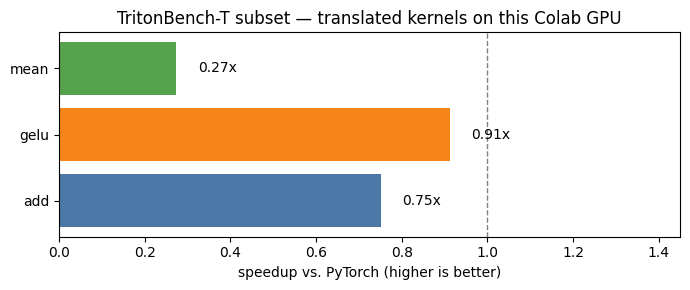

In [25]:
import matplotlib.pyplot as plt

labels  = list(results.keys())
speeds  = [results[k][2] for k in labels]

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(labels, speeds, color=["#4C78A8", "#F58518", "#54A24B"][:len(labels)])
ax.axvline(1.0, ls="--", c="gray", lw=1)
ax.set_xlabel("speedup vs. PyTorch (higher is better)")
ax.set_title("TritonBench-T subset — translated kernels on this Colab GPU")
for b, s in zip(bars, speeds):
    ax.text(b.get_width() + 0.05, b.get_y() + b.get_height()/2, f"{s:.2f}x", va="center")
lo, hi = min(speeds + [1.0]), max(speeds + [1.0])
ax.set_xlim(0, hi * 1.25 + 0.2)
plt.tight_layout(); plt.show()


## 13. Summary and exercises

### What we saw

- **Translation pipeline:** PyTorch source → LLM prompt → extracted code →
  call@1 → exe@1 → speedup.
- **The silent-bug pattern:** forgetting `/n` in `mean` passes call@1 and
  fails exe@1. This is the failure mode TritonBench was specifically
  designed to catch.
- **Fusion is where Triton wins.** Single-op translations of pointwise and
  simple-reduction kernels rarely beat PyTorch, because PyTorch is already a
  single well-tuned CUDA kernel. Real speedups come from *fusing* ops that
  PyTorch would run as separate kernels.

### Caveats

- 3-kernel subset — don't compare our numbers to the paper's.
- Simplified `mean` test harness — full benchmark requires `dim`/`keepdim`.
- No multi-GPU parallel harness; ours is single-process.
- LLM output is stochastic. Re-running can change call@1 / exe@1 results.

### Exercises

1. **Fix the bug.** The mutated `mean` dropped `/n`. Write a *different*
   silent bug that also passes call@1 and fails exe@1 (hint: the value
   passed as `other=0.0` to `tl.load`).
2. **Pick a fused kernel.** Try `mul_relu.py` or `add_gelu.py` from the
   TritonBench-T data folder. These are the kernels where Triton *should*
   beat PyTorch. Does your LLM translation win?
3. **Prompt ablation.** Remove `PROMPT_SUFFIX` from `build_prompt` and
   re-run. How often does the LLM now produce code whose wrapper has a
   different name from the reference, causing call@1 to fail?
4. **Compare models.** Change `NVIDIA_MODEL` to another model from the
   NVIDIA catalog (e.g., `meta/llama-3.1-70b-instruct`,
   `qwen/qwen2.5-coder-32b-instruct`,
   `nvidia/llama-3.1-nemotron-70b-instruct`). Which model passes more
   exe@1 checks? Which produces faster Triton? Keep `temperature`, `top_p`,
   and `seed` fixed so the comparison is fair.
5. **Contrast with G.** The G-track notebook showed the same `add_example`
   kernel. Diff that kernel against what your LLM just produced for `add`.
   Where are the differences coming from — task framing, or the model
   itself?

---

*References:*
- Wang et al., *TRITONBENCH*, arXiv:2502.14752.
- <https://github.com/thunlp/TritonBench>
- Official eval scripts: `EVAL/eval_T/{0_call_acc,1_exe_acc,2_efficiency}.py`.
